# Stock Market Analysis & Prediction using LSTM

**Stocks Analyzed:** Apple, Google, Microsoft, Amazon, Tesla, Nvidia, Meta.
**Data Source:** Yahoo Finance via yfinance
**Time Period:** Last 10 years
**Prediction Target:** Apple(AAPL) Closing Price using LSTM

## Table of Contents


## Key Questions we are asking;

1. What was the change in price of the stock over time?

2. What was the daily return of the stock on average?
3. What was the moving average of the various stocks?
4. What was the correlation between different stocks'?
5. How much value do we put at risk by investing in a particular stock?
6. How can we attempt to predict future stock behavior? (Predicting the closing price stock price of APPLE inc using LSTM)



<a id='1'></a>
## ⚙️ 1. Environment Setup

Install and import all required libraries.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np 
import yfinance as yf
from datetime import datetime, timedelta

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('darkgrid')
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# Machine Learning libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")








✅ All libraries imported successfully!
TensorFlow version: 2.15.0
NumPy version: 1.26.4
Pandas version: 3.0.1


In [2]:
import sys, platform
print("Python:", sys.version)
print("OS:", platform.version())

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
OS: 10.0.26200


In [3]:
import cpuinfo
print(cpuinfo.get_cpu_info()['flags'])

['3dnow', '3dnowprefetch', 'abm', 'acpi', 'adx', 'aes', 'apic', 'avx', 'avx2', 'bmi1', 'bmi2', 'clflush', 'clflushopt', 'clwb', 'cmov', 'cx16', 'cx8', 'de', 'dts', 'erms', 'est', 'f16c', 'fma', 'fpu', 'fxsr', 'gfni', 'ht', 'hypervisor', 'ia64', 'intel_pt', 'invpcid', 'lahf_lm', 'mca', 'mce', 'mmx', 'monitor', 'movbe', 'msr', 'mtrr', 'osxsave', 'pae', 'pat', 'pbe', 'pcid', 'pclmulqdq', 'pdcm', 'pge', 'pni', 'popcnt', 'pse', 'pse36', 'rdpid', 'rdrnd', 'rdseed', 'sep', 'serial', 'sha', 'smap', 'smep', 'ss', 'sse', 'sse2', 'sse4_1', 'sse4_2', 'ssse3', 'tm', 'tm2', 'tsc', 'tscdeadline', 'umip', 'vaes', 'vme', 'vpclmulqdq', 'x2apic', 'xsave', 'xtpr']


In [2]:
# Config

TICKERS = {
    'GOOGL': 'Google',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'TSLA': 'Tesla',
    'NVDA': 'NVIDIA'
}

END = datetime.now()
START = datetime(END.year - 10, END.month, END.day)

# Download & tag
frames = {}
for ticker, name in TICKERS.items():
    df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
    df.columns = df.columns.get_level_values(0) # Flatten multi-index columns
    df['company_name'] = name.upper() # Add company name column
    frames[ticker] = df
    
# Combine & clean
df = pd.concat(frames.values(), axis=0).sort_index()
df.index.name = 'date'
print(df.tail(10))

Price            Close        High         Low        Open     Volume  \
date                                                                    
2026-03-23  302.059998  305.980011  300.929993  302.109985   29326900   
2026-03-23  175.639999  178.369995  174.759995  177.259995  182836300   
2026-03-23  380.850006  385.329987  372.730011  373.089996   74606000   
2026-03-24  207.240005  209.350006  206.639999  207.884995   34266291   
2026-03-24  383.029999  387.470001  376.309998  376.695007   59674483   
2026-03-24  290.440002  299.920013  290.334991  299.109985   36679100   
2026-03-24  592.919983  601.000000  591.000000  599.099976   10647042   
2026-03-24  251.639999  254.824997  249.550003  250.490005   27882961   
2026-03-24  372.739990  382.470001  371.850006  382.410004   40186581   
2026-03-24  175.199997  176.220001  173.979996  174.761993  142336713   

Price      company_name  
date                     
2026-03-23       GOOGLE  
2026-03-23       NVIDIA  
2026-03-23        T

In [3]:
df.head()

Price,Close,High,Low,Open,Volume,company_name
date,,,,,,
2016-03-28,37.355263,37.604205,37.293771,37.498575,21676000,GOOGLE
2016-03-28,23.823477,24.049957,23.794033,24.006925,77645600,APPLE
2016-03-28,0.852643,0.856315,0.841627,0.842606,265388000,NVIDIA
2016-03-28,47.109257,47.769173,46.924481,47.698781,17025100,MICROSOFT
2016-03-28,15.350667,15.654000,15.000000,15.440667,58885500,TESLA


In [4]:
df.info()



<class 'pandas.DataFrame'>
DatetimeIndex: 17591 entries, 2016-03-28 to 2026-03-24
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         17591 non-null  float64
 1   High          17591 non-null  float64
 2   Low           17591 non-null  float64
 3   Open          17591 non-null  float64
 4   Volume        17591 non-null  int64  
 5   company_name  17591 non-null  str    
dtypes: float64(4), int64(1), str(1)
memory usage: 962.0 KB


In [6]:
df.shape

(17591, 6)

<a id='3'></a>
### 📊 Q1 — What was the change in price of the stock over time?

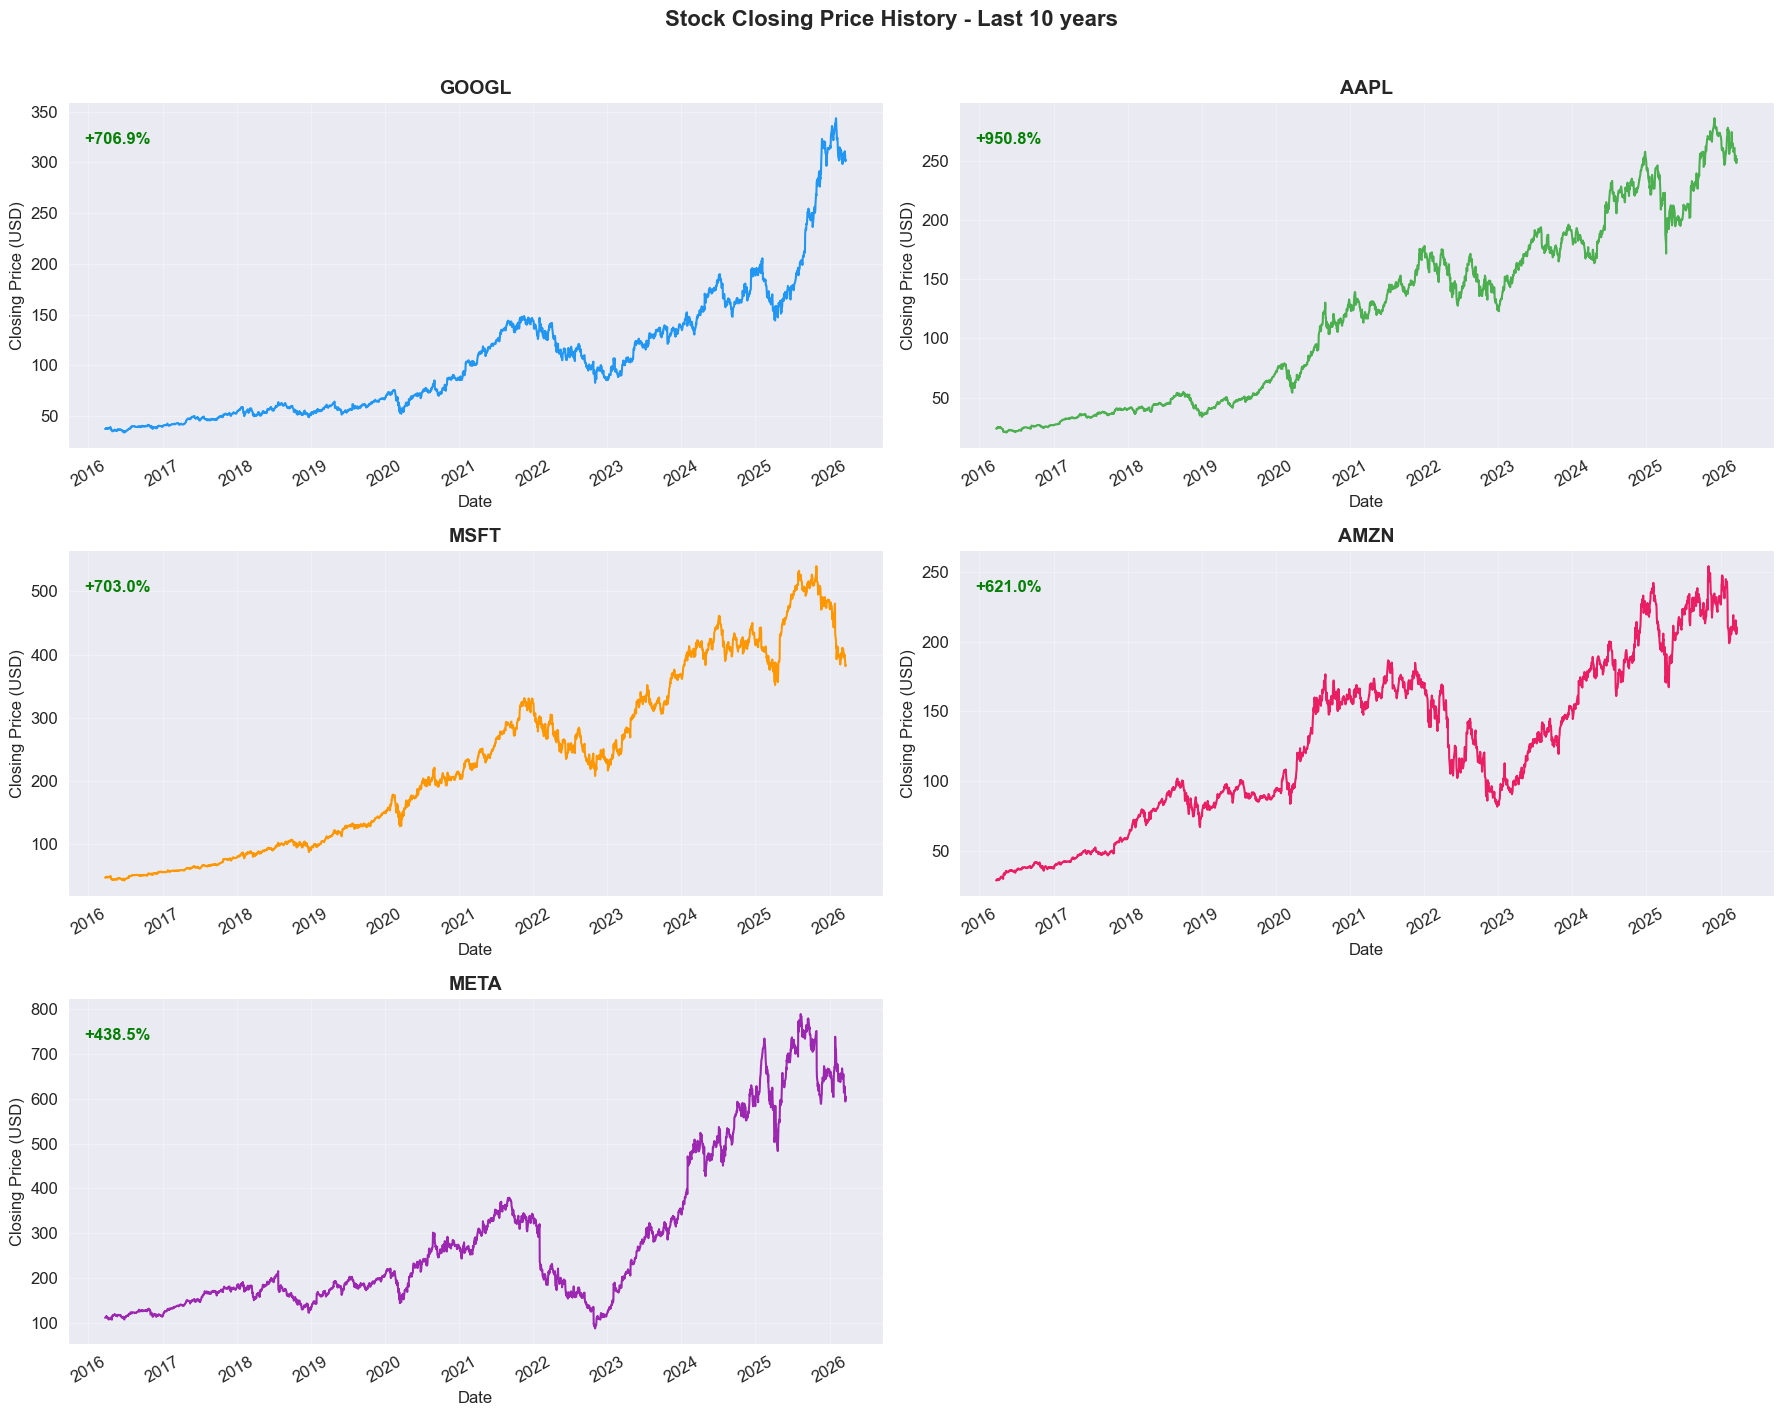

In [4]:
# -- Plot 1: Individual closing price history--

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Stock Closing Price History - Last 10 years', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(TICKERS, PALETTE)):
    df = frames[ticker]
    axes[i].plot(df.index, df['Close'], color=color, linewidth=1.5, label=ticker)
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Closing Price (USD)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
    
    # Annotate total return
    start_p = df['Close'].iloc[0]
    end_p = df['Close'].iloc[-1]
    pct_chg = ((end_p - start_p) / start_p) * 100
    axes[i].annotate(
        f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
        xy=(0.02, 0.88), xycoords='axes fraction', 
        fontsize=12, fontweight='bold',
        color='green' if pct_chg >= 0 else 'red'
    )
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()
    

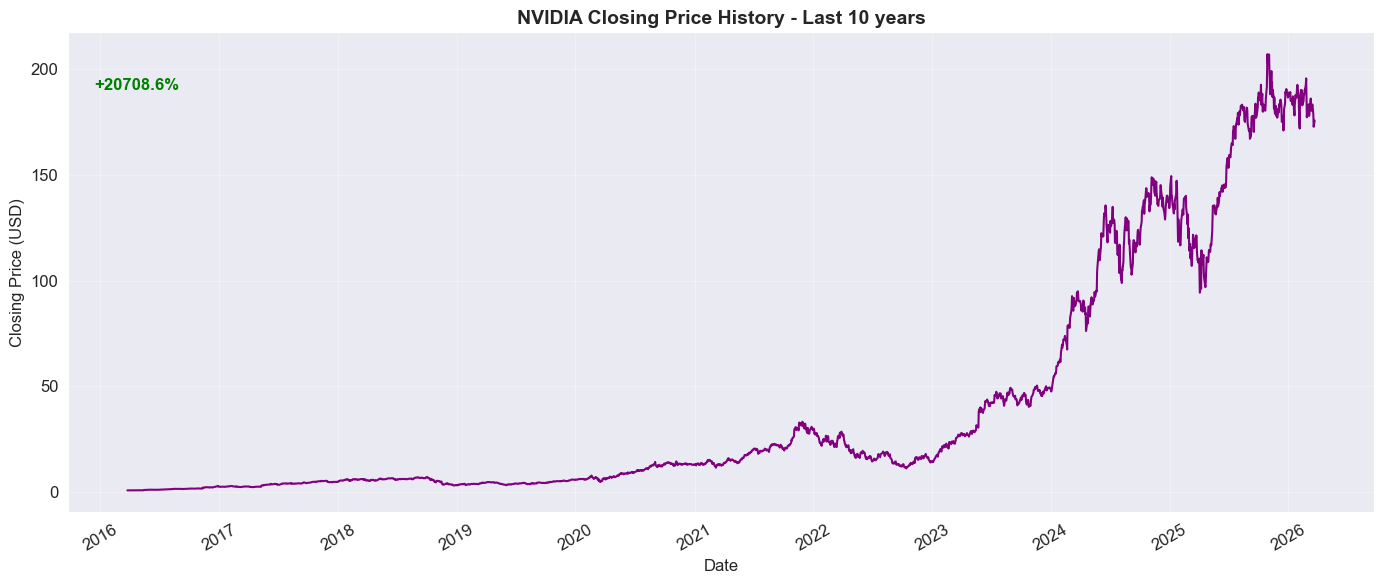

In [6]:
# -- Plot: NVIDIA Closing Price History --

df_nvda = frames['NVDA']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_nvda.index, df_nvda['Close'], color='purple', linewidth=1.5, label='NVDA')
ax.set_title('NVIDIA Closing Price History - Last 10 years', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)

# Annotate total return
start_p = df_nvda['Close'].iloc[0]
end_p = df_nvda['Close'].iloc[-1]
pct_chg = ((end_p - start_p) / start_p) * 100
ax.annotate(
    f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
    xy=(0.02, 0.88), xycoords='axes fraction', 
    fontsize=12, fontweight='bold',
    color='green' if pct_chg >= 0 else 'red'
)

plt.tight_layout()
plt.savefig('nvidia_closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()

* All the companys took a deep in 2023 and 2025, the stock closing prices went down. What exactly happened?

**Key Questions to ask**
1. What are the macro and micro economic situations affecting the globe or US?
2. Are there other  factors that could have contributed to that?
3. Could it be AI?

Is there a correlation between all this? or was it random or by chance?


In [7]:
closing_prices = pd.DataFrame(
    {ticker: frames[ticker]['Close'] for ticker in TICKERS}
)
print(closing_prices.head())

                GOOGL       AAPL       MSFT       AMZN        META       TSLA  \
Date                                                                            
2016-03-28  37.355263  23.823477  47.109257  28.993500  112.804771  15.350667   
2016-03-29  37.980587  24.387424  48.138725  29.693001  115.235687  15.342000   
2016-03-30  38.102089  24.813194  48.437885  29.934500  113.806900  15.126000   
2016-03-31  37.832317  24.684103  48.596272  29.681999  113.211578  15.318000   
2016-04-01  38.168045  24.910591  48.895424  29.924999  115.156303  15.839333   

                NVDA  
Date                  
2016-03-28  0.852643  
2016-03-29  0.866351  
2016-03-30  0.875409  
2016-03-31  0.872227  
2016-04-01  0.884956  


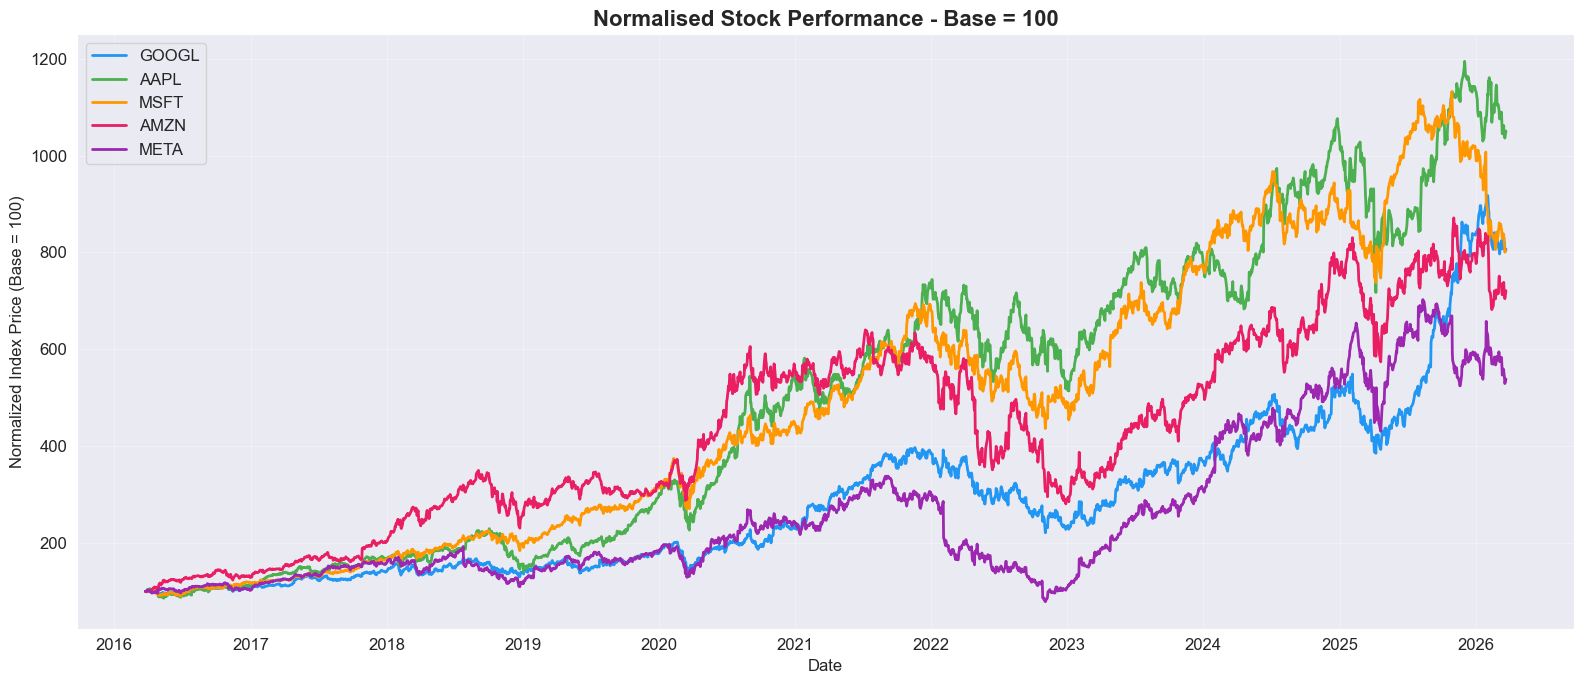


📊 Stock Performance Summary (Last 10 years) 📊



,Start Price ($),End Price ($),Max Price ($),Min Price ($),Total Return (%)
GOOGL,37.43,302.06,343.45,33.78,706.94
AAPL,23.93,251.49,285.92,20.58,950.84
MSFT,47.70,383.00,539.83,42.91,702.96
AMZN,29.15,210.14,254.00,28.99,620.95
META,112.17,604.06,788.15,88.22,438.52
TSLA,15.18,380.85,489.88,11.93,2408.34
NVDA,0.84,175.64,207.02,0.84,20708.58


In [8]:
# Plot 2: Normalized closing price history(Base = 100)
normalized = closing_prices / closing_prices.iloc[0] * 100

plt.figure(figsize=(16, 7))
for ticker, color in zip(TICKERS, PALETTE):
    plt.plot(normalized.index, normalized[ticker], label=ticker, color=color, linewidth=2)

plt.title('Normalised Stock Performance - Base = 100', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Index Price (Base = 100)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('normalized_stock_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# -- Summary table

summary = pd.DataFrame({
    'Start Price ($)': closing_prices.iloc[0],
    'End Price ($)': closing_prices.iloc[-1],
    'Max Price ($)': closing_prices.max(),
    'Min Price ($)': closing_prices.min(),
    'Total Return (%)': ((closing_prices.iloc[-1] - closing_prices.iloc[0]) / closing_prices.iloc[0]) * 100
}).round(2)

print('\n📊 Stock Performance Summary (Last 10 years) 📊\n')
summary



Across all the companies, the start price and the end price has significantly increased for  500% return over the 10 years.
Though NVIDIA has the lowest start price and end price, it's stock price grew by the largest percentage over the last 10 years. This can be attributed to factors like the emergency and growth of AI  ang gaming. Meta had the highest starting price and end price with a minimal percentage change in terms of retuns compared to the other tech companies.

Will this bull/ bubble market burst like the housing and mortgage market in 2008?

<a id='4'></a>
###  📉 Q2 — What was the daily return of the stock on average?

In [8]:
# -- Compute daily % returns --
daily_returns = closing_prices.pct_change().dropna() * 100

print("\n📈 Daily Percentage Returns (First 5 rows) 📈\n")
stats = daily_returns.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.columns = ['Mean (%)', 'Std Dev (%)', 'Min (%)', '25th %', 'Median (%)', '75th %', 'Max (%)']
stats = stats.round(4)
print(stats)        


📈 Daily Percentage Returns (First 5 rows) 📈

       Mean (%)  Std Dev (%)  Min (%)  25th %  Median (%)  75th %  Max (%)
GOOGL    0.0981       1.8124 -11.6342 -0.7668      0.1275  1.0047  10.2244
AAPL     0.1105       1.8228 -12.8647 -0.7088      0.1001  0.9889  15.3288
MSFT     0.0967       1.6926 -14.7390 -0.6665      0.1024  0.9608  14.2168
AMZN     0.0992       2.0455 -14.0494 -0.8873      0.1166  1.1385  13.5359
META     0.0955       2.4133 -26.3901 -0.9552      0.0905  1.2290  23.2824
TSLA     0.1969       3.7174 -21.0628 -1.7381      0.1244  1.9780  22.6900
NVDA     0.2610       3.1376 -18.7559 -1.3190      0.2791  1.8544  29.8067


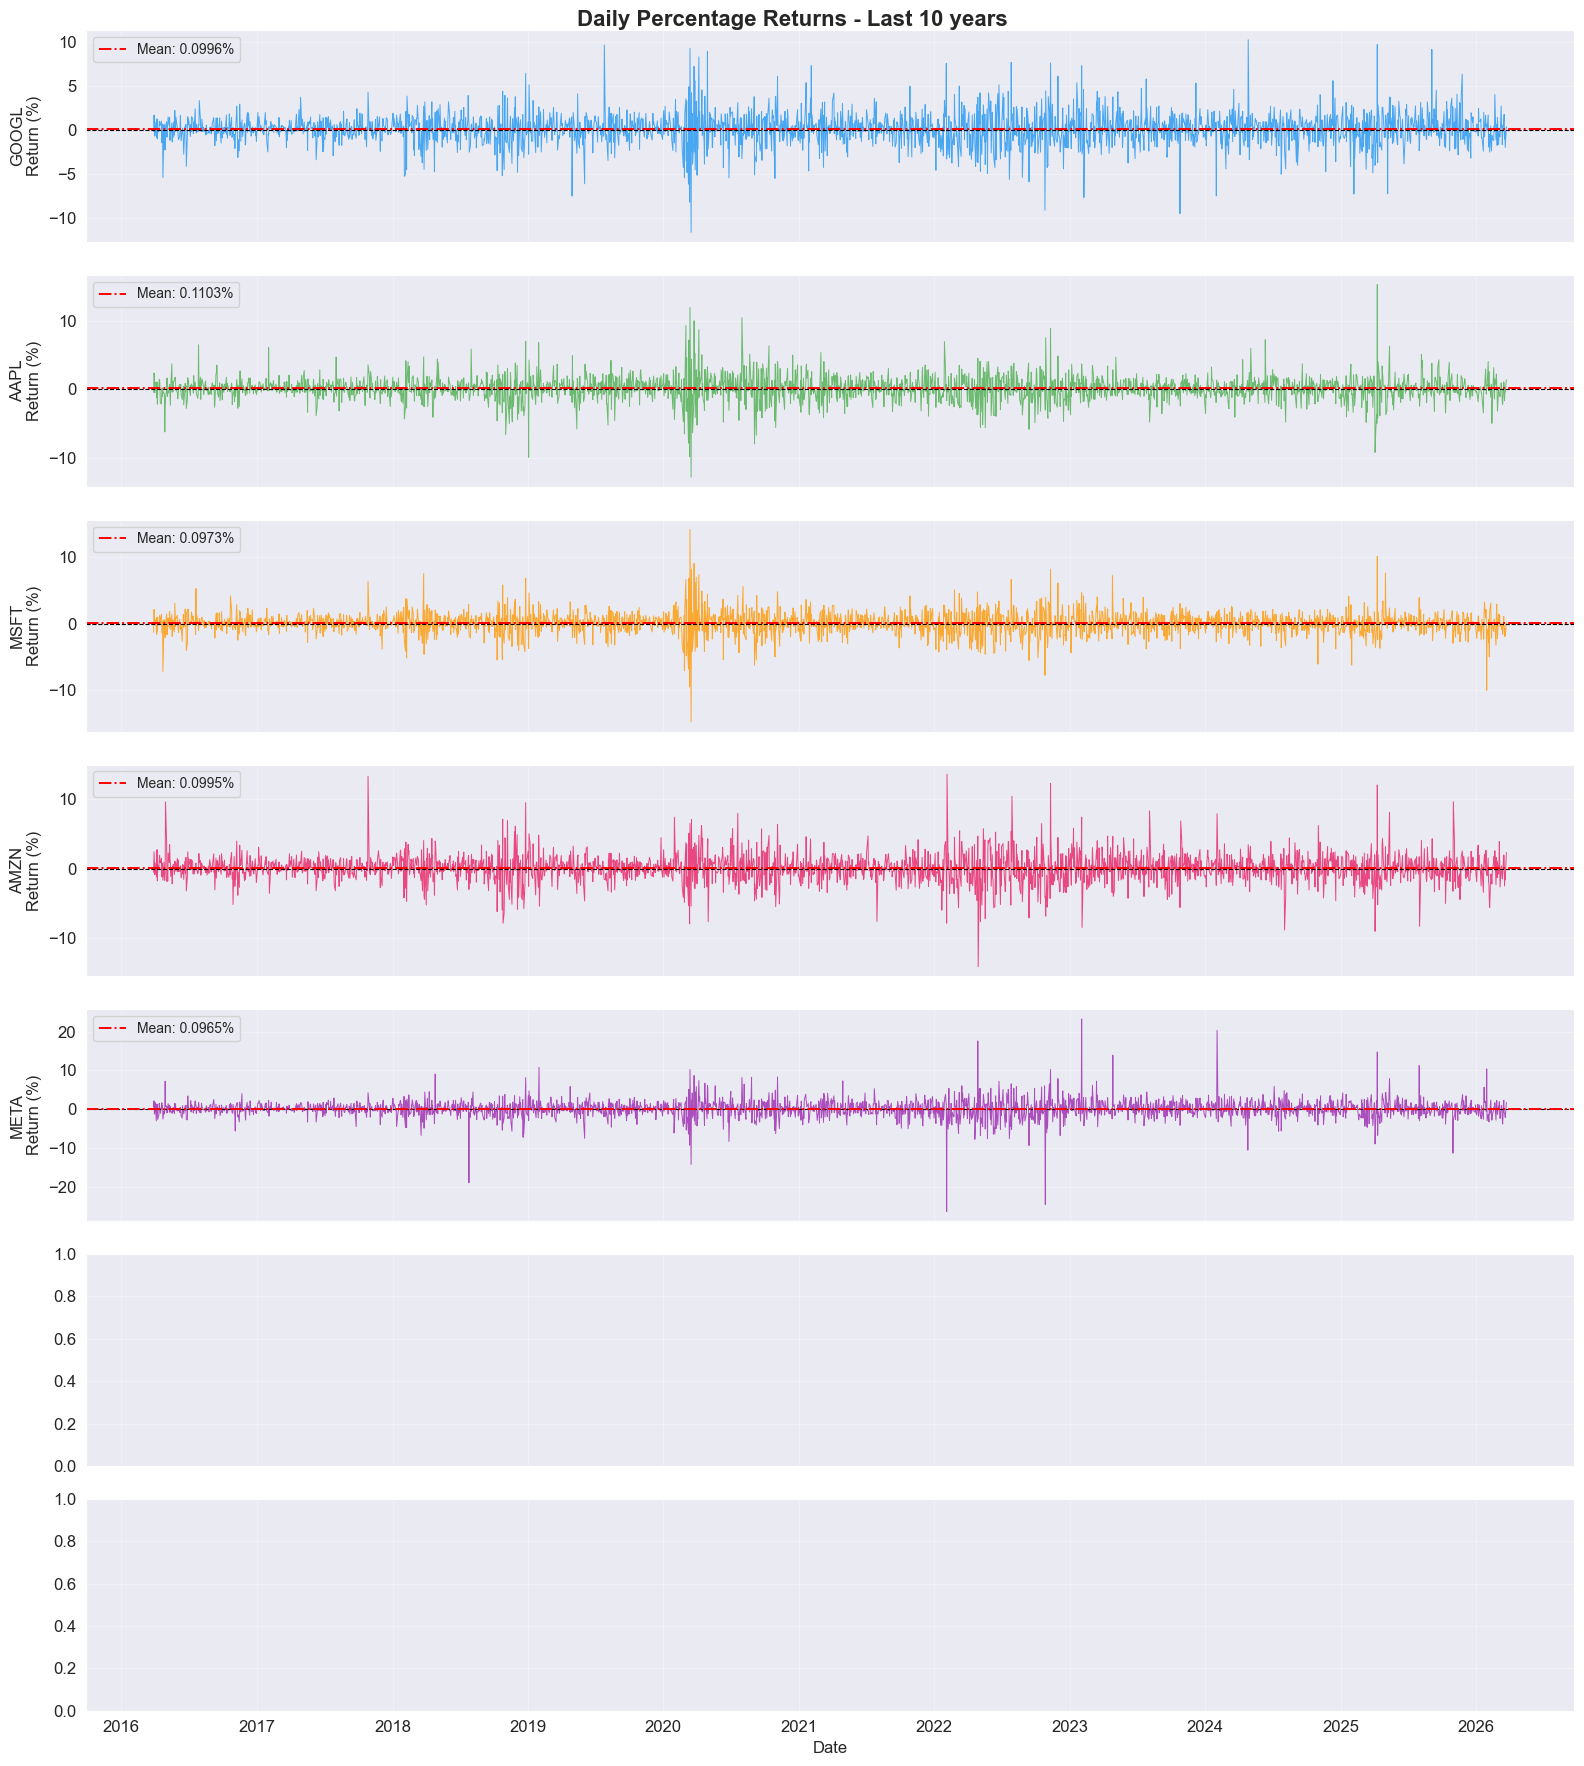

In [11]:
# Plot 3: Daily returns time-series
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(16, 18), sharex=True)
fig.suptitle('Daily Percentage Returns - Last 10 years', fontsize=16, fontweight='bold')

for ax, ticker, color in zip(axes, TICKERS, PALETTE):
    ret = daily_returns[ticker]
    ax.plot(ret.index, ret, color=color, linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8,  linestyle='--')
    ax.axhline(ret.mean(), color='red',   linewidth=1.4,  linestyle='-.',
               label=f'Mean: {ret.mean():.4f}%')
    ax.set_ylabel(f'{ticker}\nReturn (%)')
    ax.legend(loc='upper left', fontsize=10)
    
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('daily_percentage_returns.png', dpi=300, bbox_inches='tight')
plt.show()

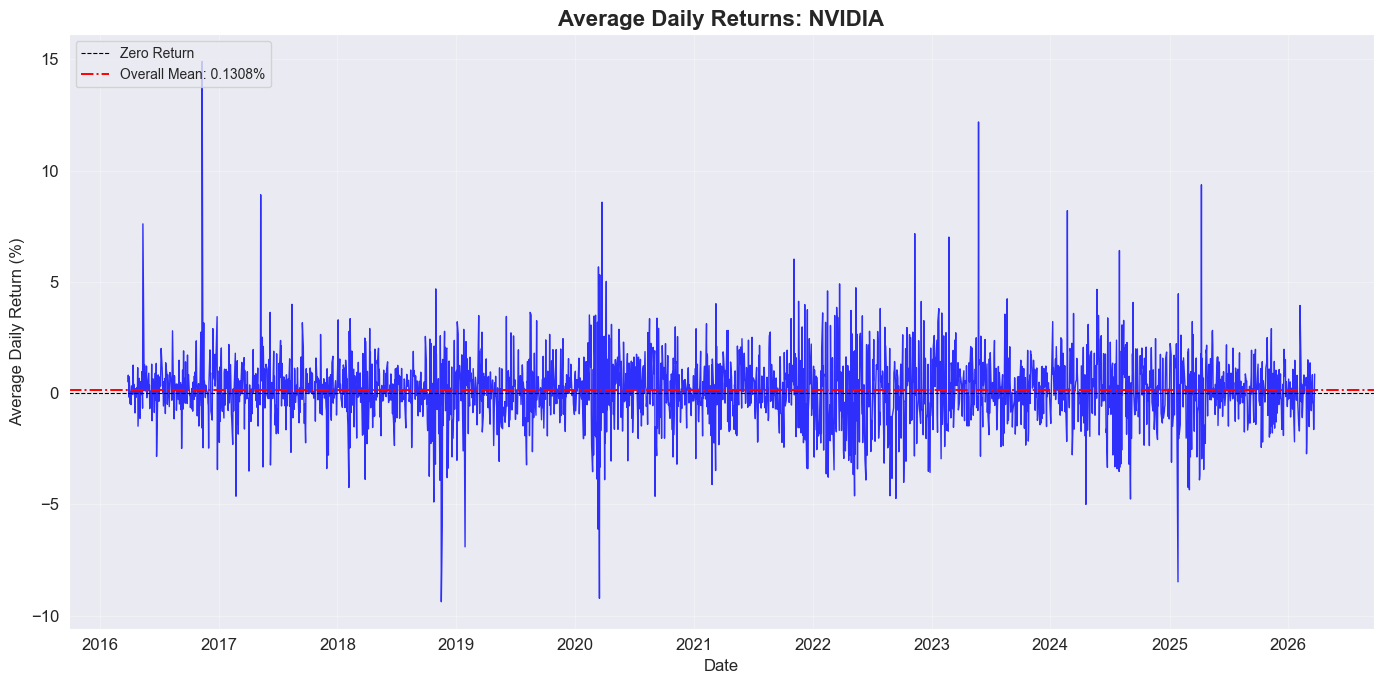

In [ ]:
# Calculate average daily returns for NVDA 
avg_daily_returns = (daily_returns['NVDA'] / 2)

# Plot the time series
plt.figure(figsize=(14, 7))
plt.plot(avg_daily_returns.index, avg_daily_returns, color='blue', linewidth=1.0, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero Return')
plt.axhline(avg_daily_returns.mean(), color='red', linewidth=1.4, linestyle='-.', 
           label=f'Overall Mean: {avg_daily_returns.mean():.4f}%')
plt.title('Average Daily Returns: NVIDIA', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Daily Return (%)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_daily_returns_nvda.png', dpi=300, bbox_inches='tight')
plt.show()

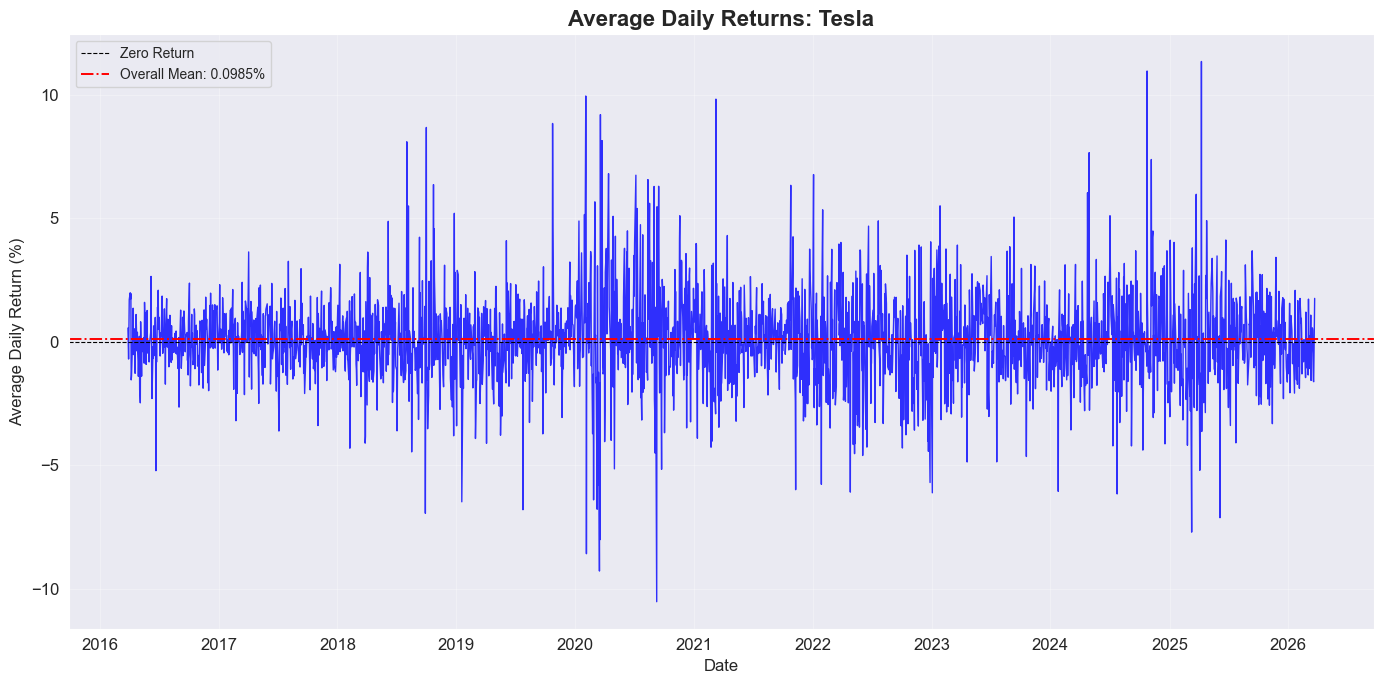

In [16]:
# Calculate average daily returns for TSLA 
avg_daily_returns = (daily_returns['TSLA'] / 2)

# Plot the time series
plt.figure(figsize=(14, 7))
plt.plot(avg_daily_returns.index, avg_daily_returns, color='blue', linewidth=1.0, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero Return')
plt.axhline(avg_daily_returns.mean(), color='red', linewidth=1.4, linestyle='-.', 
           label=f'Overall Mean: {avg_daily_returns.mean():.4f}%')
plt.title('Average Daily Returns: Tesla', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Daily Return (%)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_daily_returns_tsla.png', dpi=300, bbox_inches='tight')
plt.show()

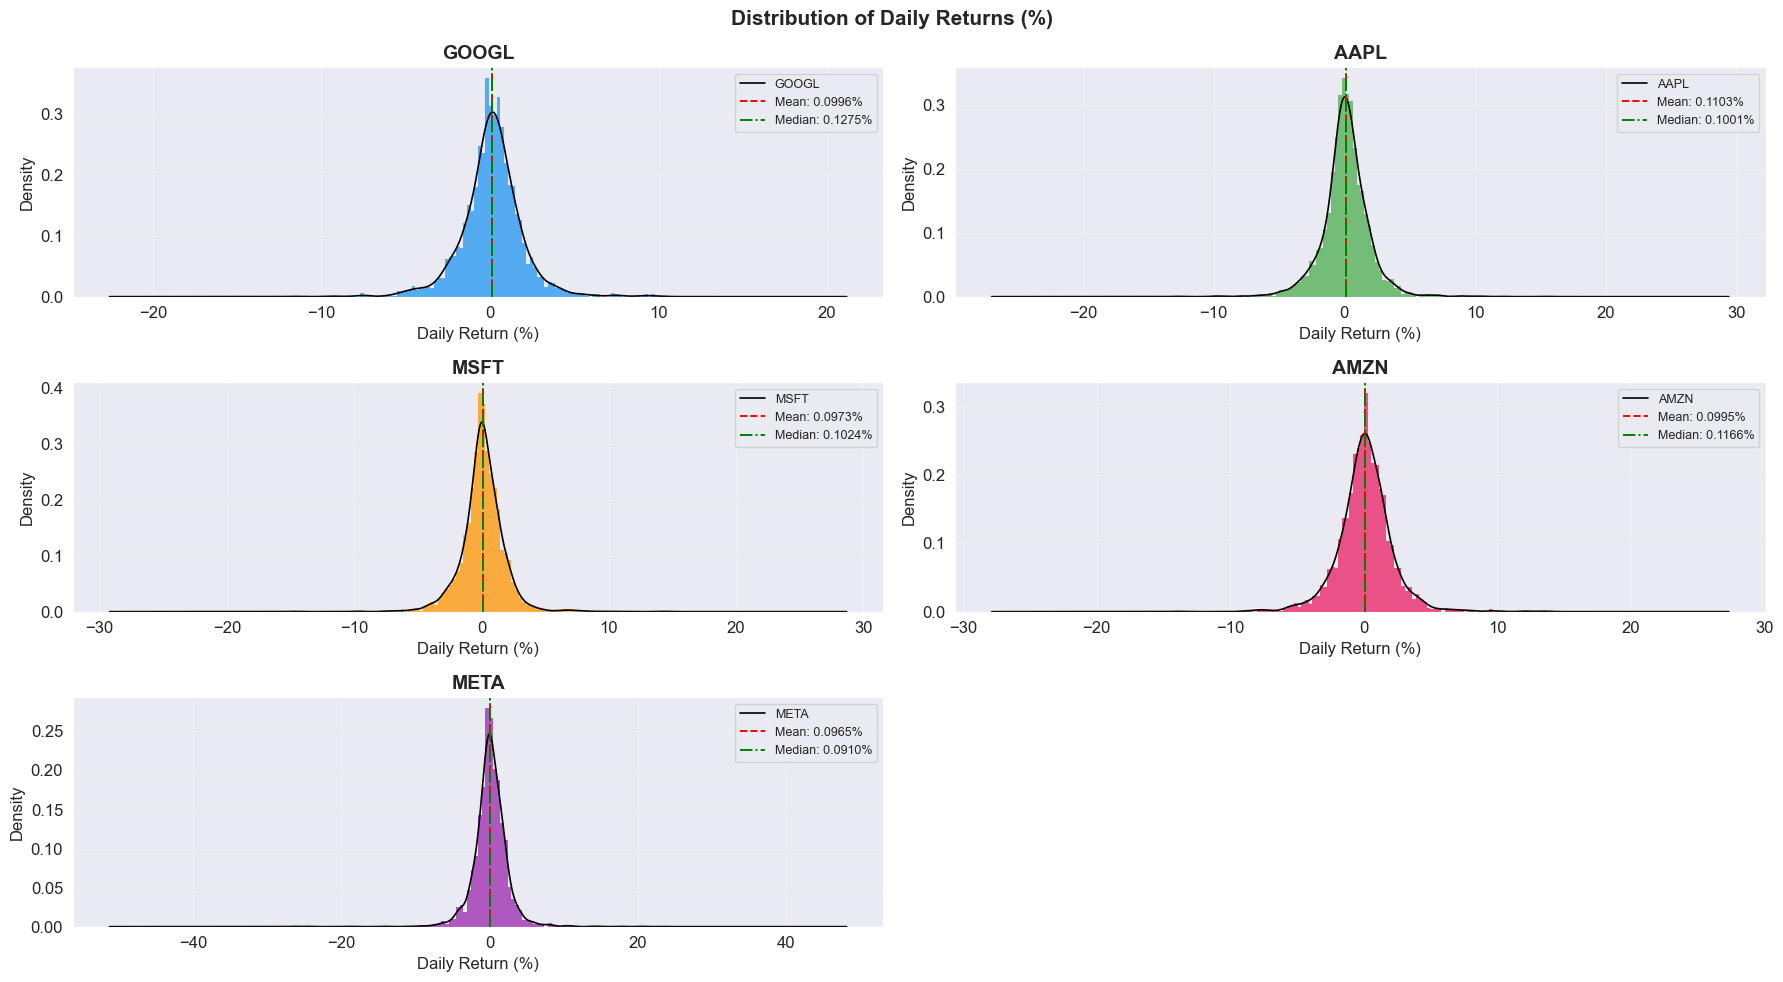

In [17]:
# Plot 4: Distribution histograms
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle('Distribution of Daily Returns (%)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(TICKERS, PALETTE)):
    ret = daily_returns[ticker]
    axes[i].hist(ret, bins=100, color=color, alpha=0.75, edgecolor='none', density=True)
    ret.plot(kind='kde', color='black', linewidth=1.2, ax=axes[i])
    axes[i].axvline(ret.mean(), color='red', linestyle='--', linewidth=1.4, label=f'Mean: {ret.mean():.4f}%')
    axes[i].axvline(ret.median(), color='green', linestyle='-.', linewidth=1.4, label=f'Median: {ret.median():.4f}%')
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('daily_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

<a id='5'></a>
### 📐 Q3 — What was the moving average of the various stocks?

In [9]:
# -- Compute MA-10, MA-20, MA-50--

MA_WINDOWS = [10, 20, 50]

for ticker in TICKERS:
    for w in MA_WINDOWS:
        frames[ticker][f'MA_{w}'] = frames[ticker]['Close'].rolling(window=w).mean()    

print("\n✅ Moving averages (MA-10, MA-20, MA-50) computed and added to each DataFrame!")


✅ Moving averages (MA-10, MA-20, MA-50) computed and added to each DataFrame!


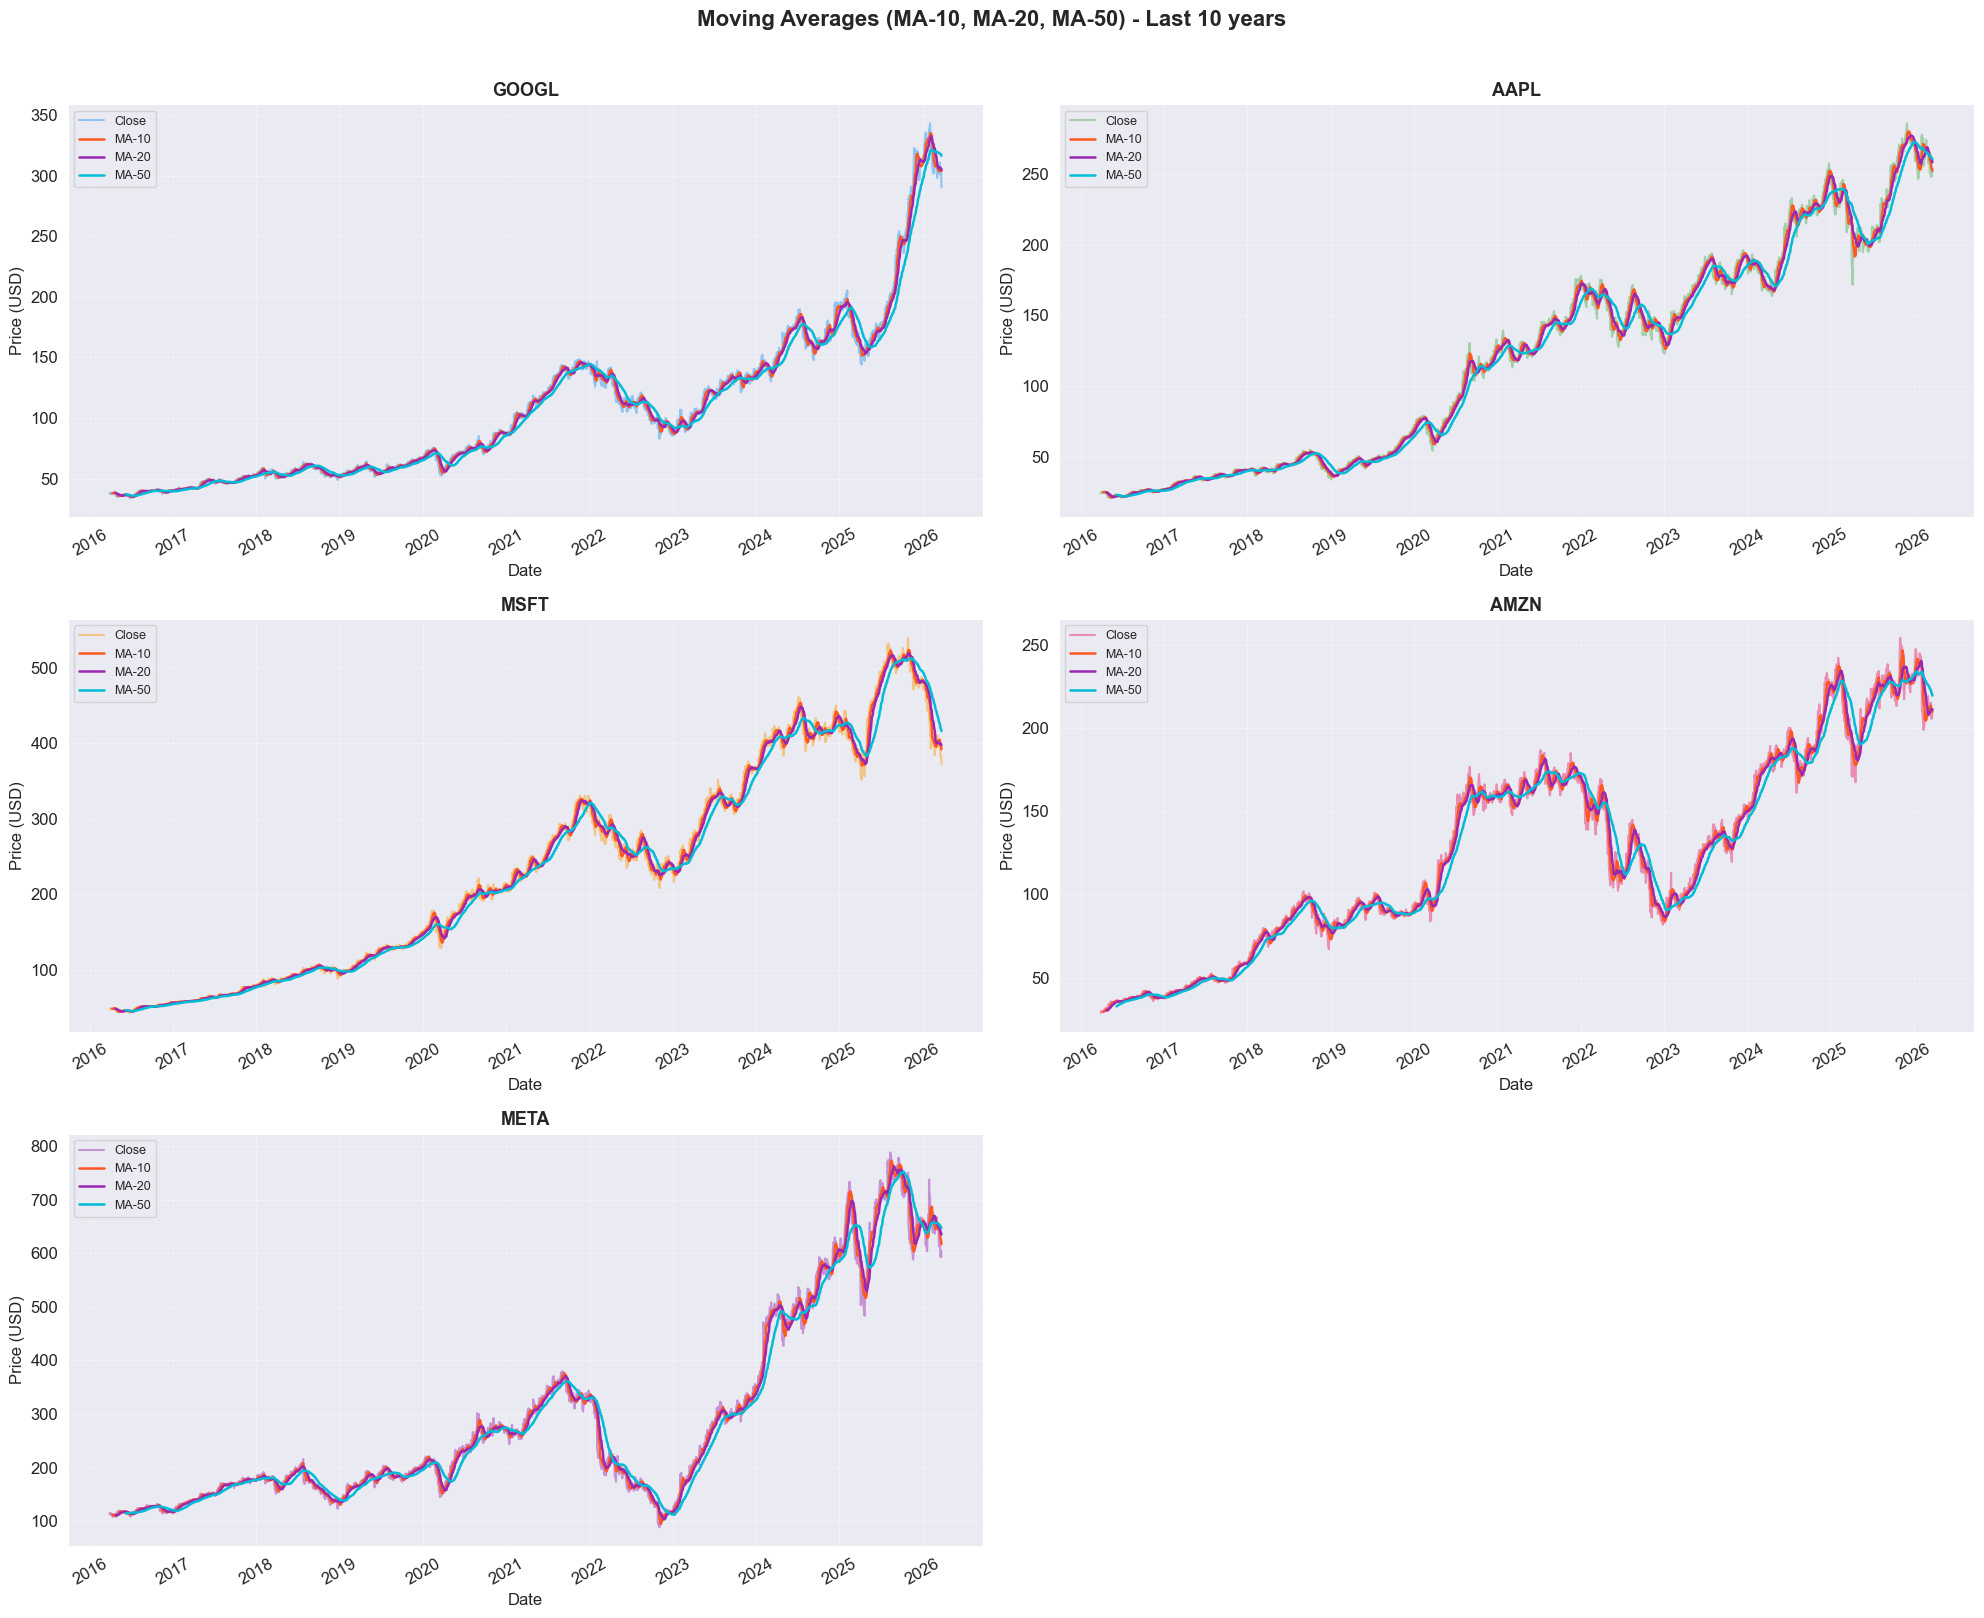

📌 MA-50 captures long-term trends; MA-10/MA-20 crossovers signal momentum shifts.


In [10]:
# -- Plot 5: Moving averages per stock --
MA_COLORS = {'MA_10': '#FF5722', 'MA_20': '#9C27B0', 'MA_50': '#00BCD4'}

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle('Moving Averages (MA-10, MA-20, MA-50) - Last 10 years', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (ticker, base_color) in enumerate(zip(TICKERS, PALETTE)):
    df = frames[ticker]
    axes[i].plot(df.index, df['Close'], color=base_color, linewidth=1.5, alpha=0.45, label='Close')
    for ma, mc in MA_COLORS.items():
        axes[i].plot(df.index, df[ma], color=mc, linewidth=1.8, label=ma.replace('_', '-'))
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price (USD)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()
print('📌 MA-50 captures long-term trends; MA-10/MA-20 crossovers signal momentum shifts.')

<a id='6'></a>
### 🔗 Q4 — What was the correlation between different stocks?

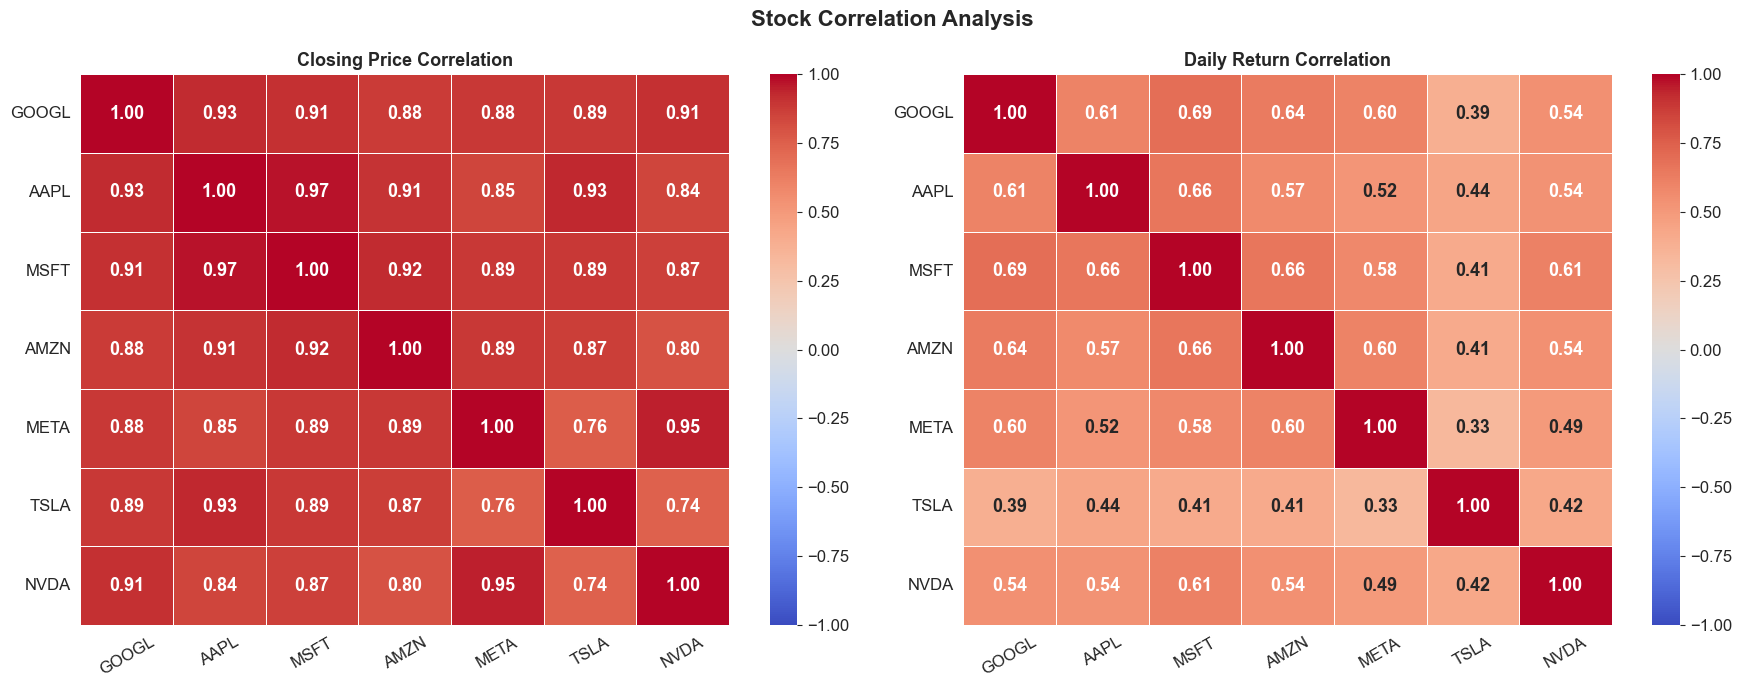

In [11]:
# -- Correlation heatmaps --
close_corr = closing_prices.corr()
return_corr = daily_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Stock Correlation Analysis', fontsize=16, fontweight='bold')

for ax, corr_matrix, title in zip(
    axes,
    [close_corr, return_corr],
    ['Closing Price Correlation', 'Daily Return Correlation']
):
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
        center=0, vmin=-1, vmax=1, ax=ax,
        linewidths=0.5, linecolor='white',
        annot_kws={"size": 13, "weight": 'bold'}  
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    
plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

⏳ Generating pairplot — this may take a few seconds...


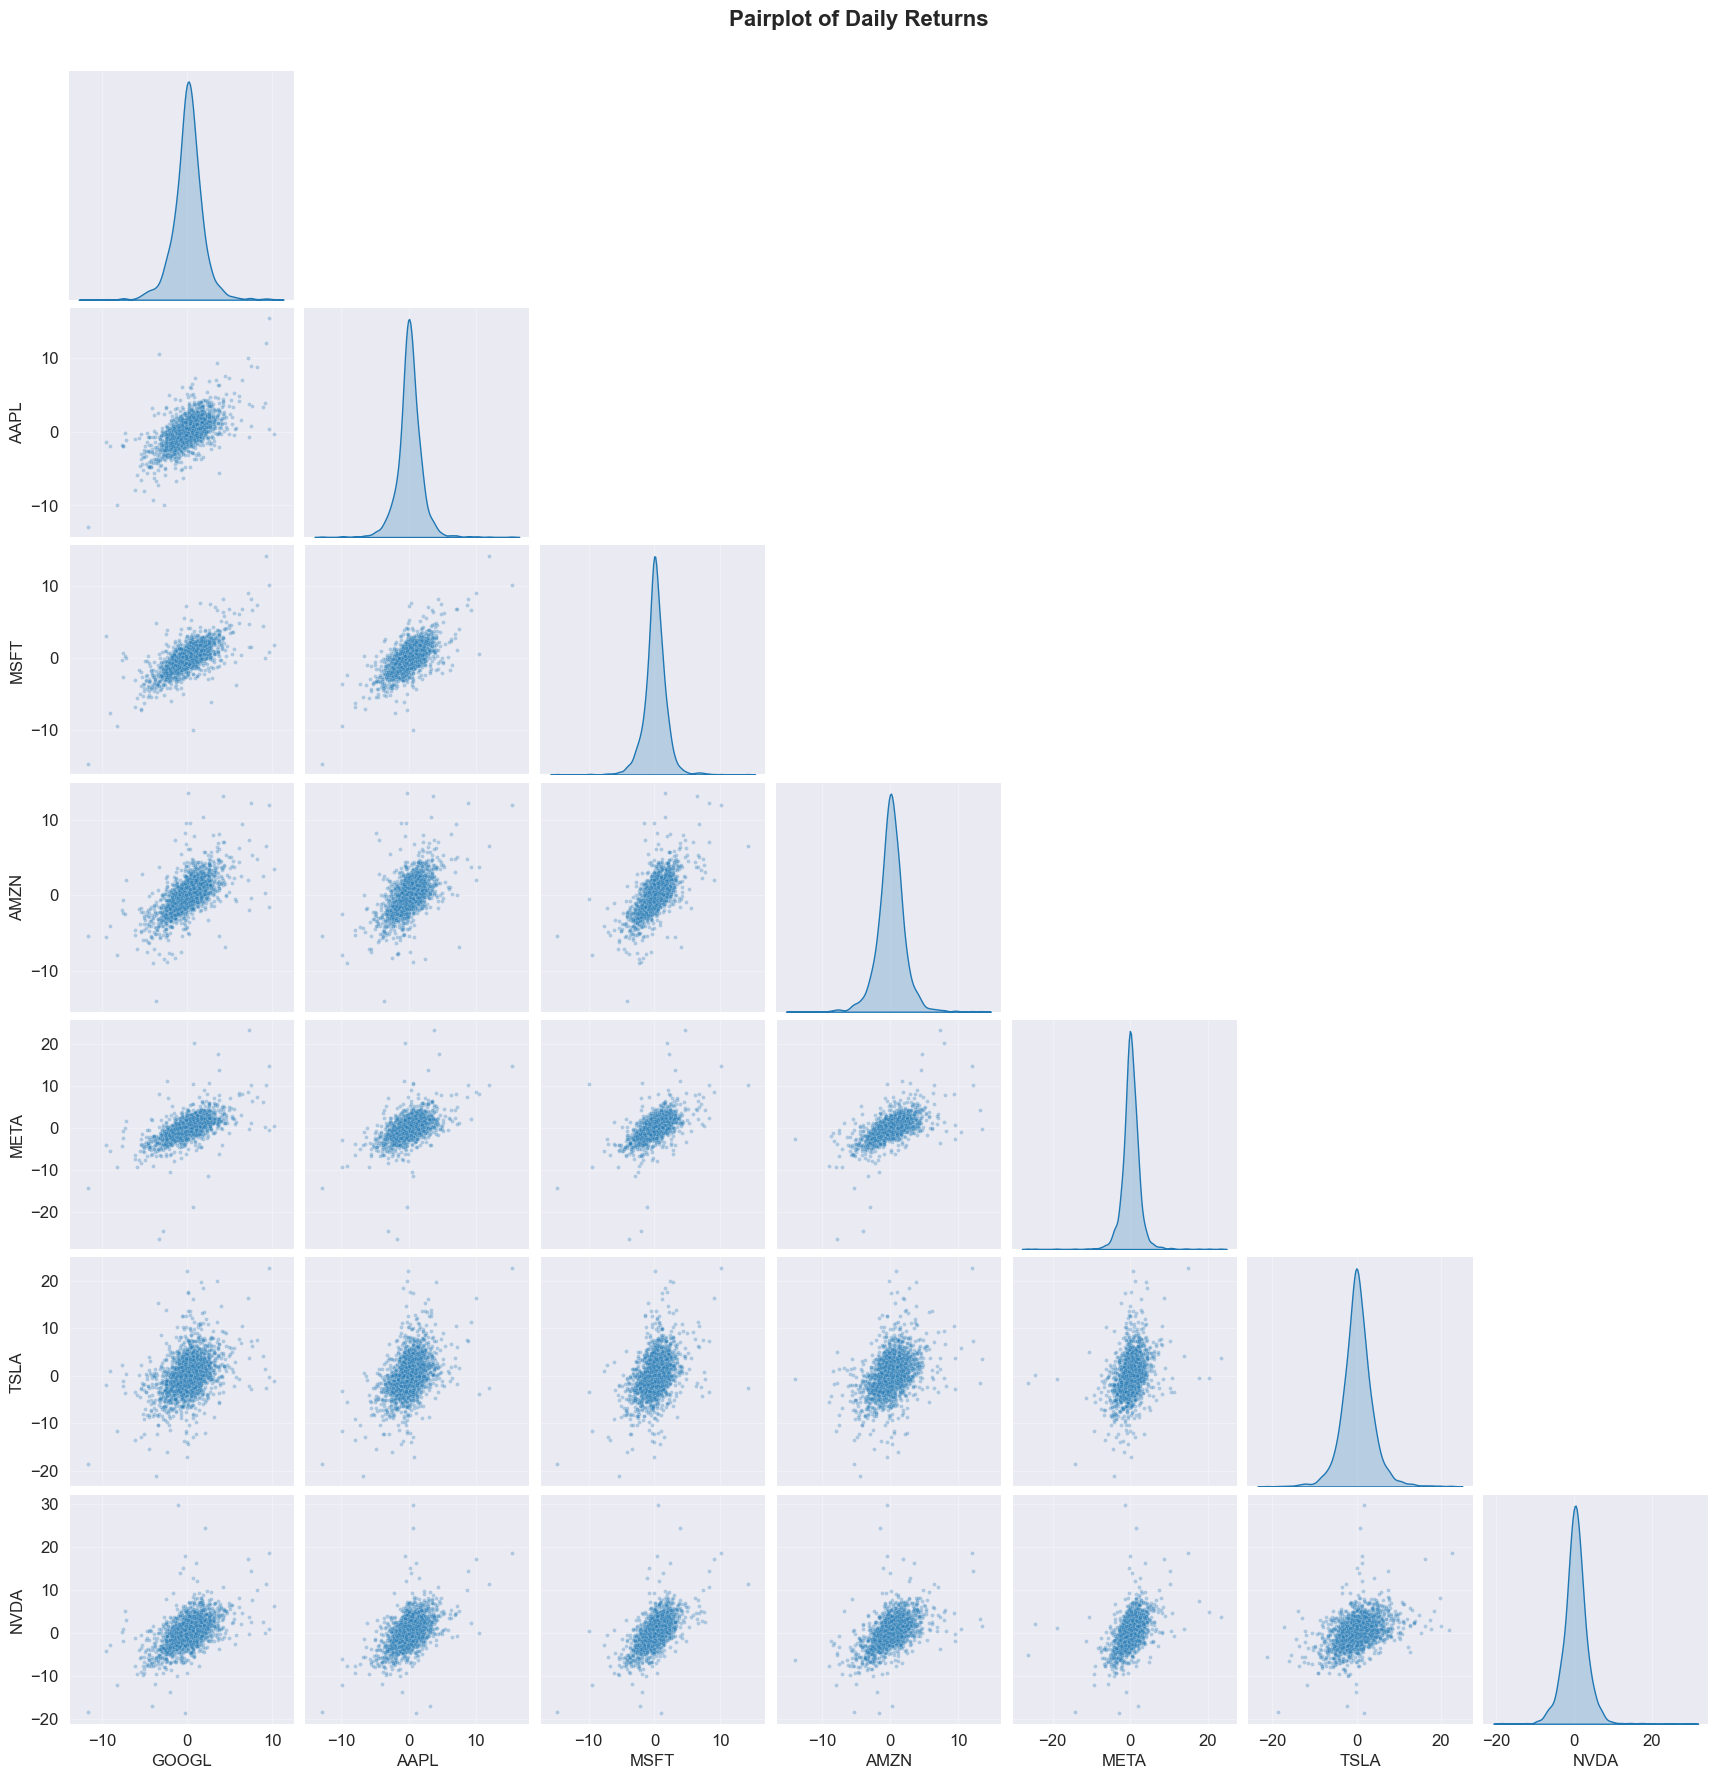


📋 Daily Return Correlation Matrix:


,GOOGL,AAPL,MSFT,AMZN,META,TSLA,NVDA
GOOGL,1.000,0.606,0.689,0.636,0.605,0.390,0.540
AAPL,0.606,1.000,0.661,0.574,0.519,0.440,0.536
MSFT,0.689,0.661,1.000,0.664,0.582,0.412,0.611
AMZN,0.636,0.574,0.664,1.000,0.602,0.409,0.539
META,0.605,0.519,0.582,0.602,1.000,0.333,0.494
TSLA,0.390,0.440,0.412,0.409,0.333,1.000,0.423
NVDA,0.540,0.536,0.611,0.539,0.494,0.423,1.000


In [12]:
# Pairplot of daily returns --
print('⏳ Generating pairplot — this may take a few seconds...')
pp = sns.pairplot(
    daily_returns.dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 8},
    diag_kws={'fill': True},
    corner=True
)
pp.figure.suptitle('Pairplot of Daily Returns', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('daily_returns_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n📋 Daily Return Correlation Matrix:')
return_corr.round(3)

<a id='7'></a>
### ⚠️ Q5 — How much value do we put at risk by investing in a particular stock?

Two approaches:
- **Historical VaR** — empirical worst-case at the chosen confidence level
- **Monte Carlo VaR** — simulated future 1-day returns via Geometric Brownian Motion

In [13]:
# -- VaR configuration --

INVESTMENT = 10_000 # USD
CONFIDENCE = 0.95 # 95%
MC_SIMULATIONS = 10_000
TIME_HORIZON = 1 # 1 day

var_results = []

for ticker in TICKERS:
    ret =  daily_returns[ticker].dropna() / 100
    
    # Historical VaR
    hist_var = np.percentile(ret, (1 - CONFIDENCE) * 100) * INVESTMENT
    
    # Monte Carlo VaR (GBM)
    mu, sigma = ret.mean(), ret.std()
    simulated = np.random.normal(
        mu * TIME_HORIZON, 
        sigma * np.sqrt(TIME_HORIZON), 
        MC_SIMULATIONS
    )
    mc_var = np.percentile(simulated, (1 - CONFIDENCE) * 100) * INVESTMENT

    var_results.append({
        'Ticker' : ticker,
        'Daily Volatility (%)': round(sigma * 100, 4),
        'Historical VaR ($)': round(abs(hist_var), 2),
        'Monte Carlo VaR ($)': round(abs(mc_var), 2),
        'Hist VaR (%)' : round((abs(hist_var) / INVESTMENT) * 100, 2),
        'MC VaR (%)' : round((abs(mc_var) / INVESTMENT) * 100, 2)
    })
    
var_df = pd.DataFrame(var_results).set_index('Ticker')
print(f'📋 VaR Summary | Investment: ${INVESTMENT:,} | Confidence: {int(CONFIDENCE*100)}%\n')
var_df

📋 VaR Summary | Investment: $10,000 | Confidence: 95%



,Daily Volatility (%),Historical VaR ($),Monte Carlo VaR ($),Hist VaR (%),MC VaR (%)
Ticker,,,,,
GOOGL,1.8124,271.36,290.12,2.71,2.90
AAPL,1.8228,277.96,282.30,2.78,2.82
MSFT,1.6926,262.95,264.01,2.63,2.64
AMZN,2.0455,306.29,327.71,3.06,3.28
META,2.4133,337.17,389.58,3.37,3.90
TSLA,3.7174,533.51,601.30,5.34,6.01
NVDA,3.1376,453.09,482.13,4.53,4.82


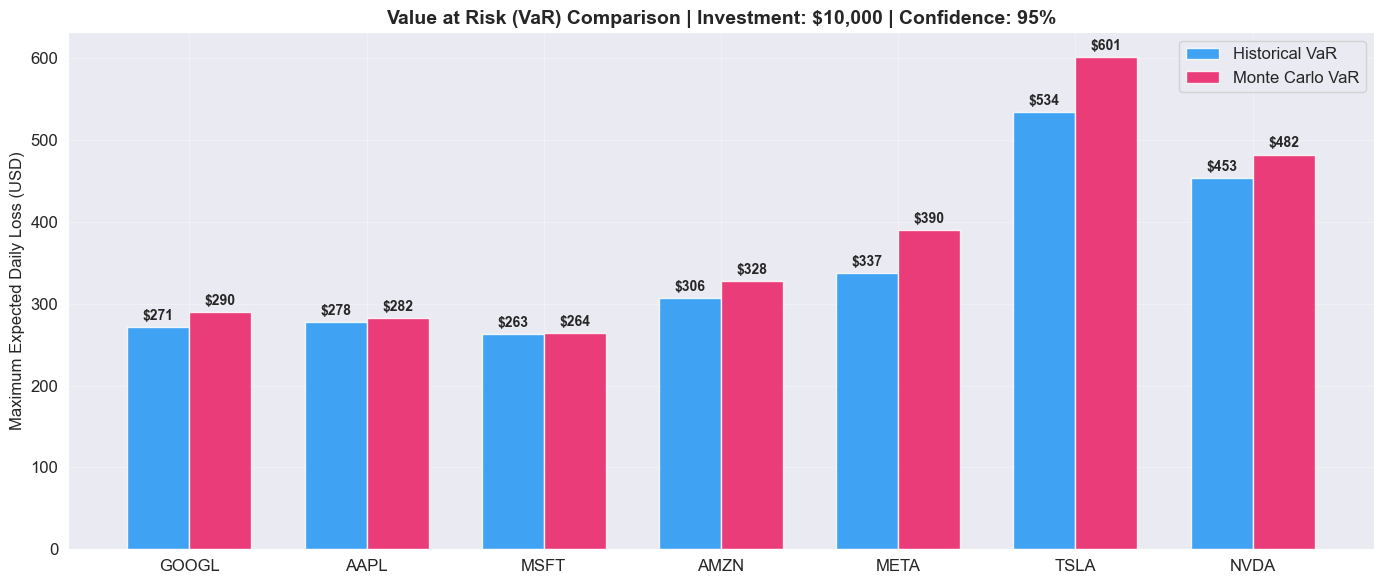

In [14]:
# - Plot 6: VaR bar chart --
from numpy import var


x = np.arange(len(TICKERS))
width = 0.35

fig, ax =  plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, var_df['Historical VaR ($)'], width, label='Historical VaR', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, var_df['Monte Carlo VaR ($)'], width, label='Monte Carlo VaR', color='#E91E63', alpha=0.85)

ax.bar_label(bars1, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')
ax.bar_label(bars2, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')
ax.set_title(f'Value at Risk (VaR) Comparison | Investment: ${INVESTMENT:,} | Confidence: {int(CONFIDENCE*100)}%', fontsize=14, fontweight='bold')
ax.set_ylabel('Maximum Expected Daily Loss (USD)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('var_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

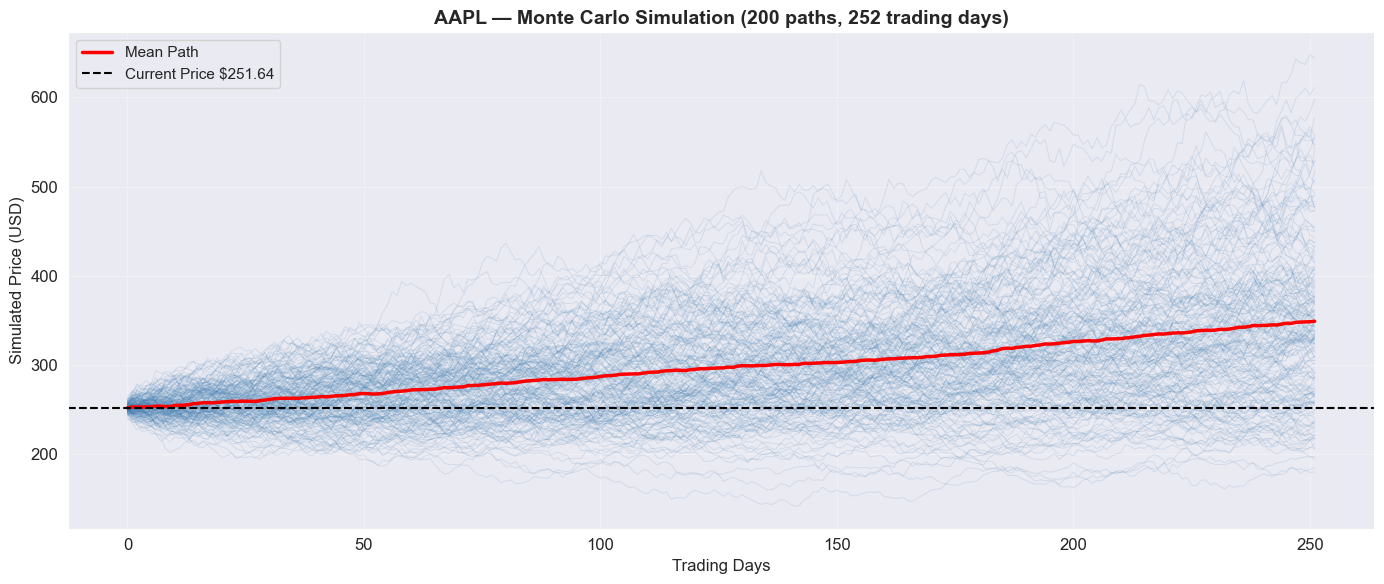

📌 AAPL after 252 trading days (simulated):
   5th  percentile : $217.86
   Mean            : $348.87
   95th percentile : $530.00


In [15]:
# -- Plot7: Monte Carlo price paths for AAPL(1 trading year) --
MC_PATHS = 200
MC_DAYS = 252 # Trading days in a year

aapl_ret = daily_returns['AAPL'].dropna() / 100
mu_a = aapl_ret.mean()
sigma_a = aapl_ret.std()
last_price = frames['AAPL']['Close'].iloc[-1]

shocks = np.random.normal(mu_a, sigma_a, (MC_DAYS, MC_PATHS))
price_paths = last_price * np.exp(np.cumsum(shocks, axis=0))

plt.figure(figsize=(14, 6))
plt.plot(price_paths, alpha=0.15, linewidth=0.7, color='steelblue')
plt.plot(price_paths.mean(axis=1), color='red', linewidth=2.5, label='Mean Path')
plt.axhline(last_price, color='black', linestyle='--', linewidth=1.5,
            label=f'Current Price ${last_price:.2f}')
plt.title(f'AAPL — Monte Carlo Simulation ({MC_PATHS} paths, {MC_DAYS} trading days)',
          fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Simulated Price (USD)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('q5_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

final_prices = price_paths[-1]
print(f'📌 AAPL after {MC_DAYS} trading days (simulated):')
print(f'   5th  percentile : ${np.percentile(final_prices,  5):.2f}')
print(f'   Mean            : ${final_prices.mean():.2f}')
print(f'   95th percentile : ${np.percentile(final_prices, 95):.2f}')


<a id='8'></a>
### 🤖 Q6 — LSTM Prediction: Apple (AAPL) Closing Price

A stacked LSTM model predicts Apple's next-day closing price.

**Architecture:** `Input(60,1)` → `LSTM(128, seq)` → `Dropout(0.2)` → `LSTM(64, seq)` → `Dropout(0.2)` → `LSTM(32)` → `Dropout(0.2)` → `Dense(32, ReLU)` → `Dense(1)`

In [ ]:
# -- 8.1 Prepare AAPL data for LSTM modeling --

LOOK_BACK = 60 # Number of past days to use for prediction
TRAIN_RATIO = 0.8 # 80% training, 20% testing

aapl_close = frames['AAPL'][['Close']].copy()

# Scale to [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
aapl_scaled = scaler.fit_transform(aapl_close)

# Chronological split
train_size = int(len(aapl_scaled) * TRAIN_RATIO)
train_data = aapl_scaled[:train_size]
test_data = aapl_scaled[train_size - LOOK_BACK:] # Include look-back for test

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0]) # Look-back window
        y.append(data[i, 0]) # Target is the next day's price
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, LOOK_BACK)
X_test, y_test = create_sequences(test_data, LOOK_BACK)

# Reshape for LSTM [samples, time steps, features]
X_train = X_train.reshape(*X_train.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

print(f'📐 X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'📐 X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'\n📅 Training : {aapl_close.index[0].date()} → {aapl_close.index[train_size].date()}')
print(f'📅 Testing  : {aapl_close.index[train_size].date()} → {aapl_close.index[-1].date()}')


In [ ]:
# -- 8.2 Build Stacked LSTM model --
model = Sequential([
    Input(shape=(LOOK_BACK, 1)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

model.summary()



In [ ]:
# -- 8.3 Train the model --
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Training complete.  Best val_loss: {min(history.history["val_loss"]):.6f}')

In [ ]:
# -- 8.4 Loss Curve --
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='Training Loss', color='#2196F3', linewidth=2) 
ax.plot(history.history['val_loss'], label='Validation Loss', color='#FF5722', linewidth=2)
ax.set_title('LSTM — Training & Validation Loss (MSE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('lstm_loss_curve.png', dpi=300, bbox_inches='tight')    
plt.show()

In [ ]:
# -- 8.5 Make Predicitions & Evaluate --
train_predict = scaler.inverse_transform(model.predict(X_train))
test_predict = scaler.inverse_transform(model.predict(X_test))
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

def eval_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:8s} | RMSE: ${rmse:7.4f} | MAE: ${mae:7.4f} | MAPE: {mape:6.2f}% | R²: {r2:.4f}')
    
print('\n📊 Model Performance Metrics 📊\n')
print('-' * 65)
eval_metrics(y_train_inv, train_predict, 'TRAIN')
eval_metrics(y_test_inv,  test_predict,  'TEST')
print('-' * 65)

In [ ]:
# -- 8.6 Full Prediction Plot (all 10 years) --
train_plot = np.full(len(aapl_scaled), np.nan)
test_plot  = np.full(len(aapl_close), np.nan)

train_plot[LOOK_BACK : LOOK_BACK + len(train_predict)] = train_predict.flatten()
test_start = LOOK_BACK + len(train_predict)
test_plot[test_start : test_start + len(test_predict)] = test_predict.flatten()

split_date = aapl_close.index[test_start]

fig, ax = plt.subplots(figsize=(18, 7))
ax.plot(aapl_close.index, aapl_close['Close'].values,
        color='#BDBDBD', linewidth=1,   alpha=0.85, label='Actual Price')
ax.plot(aapl_close.index, train_plot,
        color='#2196F3', linewidth=1.5,              label='Train Prediction')
ax.plot(aapl_close.index, test_plot,
        color='#E91E63', linewidth=2,                label='Test Prediction')
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5,
           label=f'Train/Test Split ({split_date.date()})')

ax.set_title('AAPL — Actual vs LSTM Predicted Closing Price', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('q6_lstm_full_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
